# 01 — Download

Download Google Fonts (TTF, all variants, non-monospaced). Extract explicit kerning pairs (GPOS then `kern` table fallback) for Latin-52 glyphs (A–Z, a–z), keeping only `kern != 0`.

**Input**: `GOOGLE_FONTS_API_KEY` from `.env`, `MAX_FONTS` (set `None` for full run).
**Output**: `data/raw/fonts/{stem}.ttf`, `data/processed/kerning_pairs.csv`, `data/processed/fonts_catalog.csv`.


In [1]:
import os
import time
import logging
from pathlib import Path
from typing import Optional

import requests
import pandas as pd
from dotenv import load_dotenv
from tqdm.auto import tqdm
from fontTools.ttLib import TTFont
from fontTools.ttLib.tables import otTables

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
log = logging.getLogger("kern")

_cwd = Path.cwd().resolve()
if (_cwd / "pyproject.toml").exists():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / "pyproject.toml").exists():
    PROJECT_ROOT = _cwd.parent
else:
    PROJECT_ROOT = _cwd
DATA_RAW = PROJECT_ROOT / "data" / "raw" / "fonts"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

MAX_FONTS: Optional[int] = None
DOWNLOAD_SLEEP_S = 0.05
GOOGLE_FONTS_API_URL = "https://www.googleapis.com/webfonts/v1/webfonts"
LATIN_52 = "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
LATIN_52_SET = set(LATIN_52)

load_dotenv(PROJECT_ROOT / ".env")
API_KEY = os.getenv("GOOGLE_FONTS_API_KEY")
if not API_KEY or API_KEY == "your_api_key_here":
    raise ValueError("GOOGLE_FONTS_API_KEY missing in .env")

log.info("Root: %s", PROJECT_ROOT)
log.info("MAX_FONTS: %s", MAX_FONTS)

2026-07-21 19:49:27,822 | INFO | Root: C:\Users\angel\OneDrive\Desktop\Kern
2026-07-21 19:49:27,823 | INFO | MAX_FONTS: None


In [2]:
MONOSPACED_KW = ("mono", "monospace", "code", "console", "courier")

def is_monospaced(family: str, category: str) -> bool:
    fam = family.lower().replace("-", " ").replace("_", " ")
    if "monospace" in (category or "").lower():
        return True
    return any(kw in fam for kw in MONOSPACED_KW)

resp = requests.get(GOOGLE_FONTS_API_URL, params={"key": API_KEY, "sort": "popularity"}, timeout=30)
resp.raise_for_status()
items = resp.json().get("items", [])
log.info("Catalog: %d fonts", len(items))

fonts = [f for f in items if not is_monospaced(f.get("family", ""), f.get("category", ""))]
log.info("After monospaced filter: %d", len(fonts))

if MAX_FONTS is not None:
    fonts = fonts[:MAX_FONTS]

print(f"Selected {len(fonts)} font families")
print(f"Total variants to download: {sum(len(f.get('files', {})) for f in fonts)}")

2026-07-21 19:49:31,092 | INFO | Catalog: 1951 fonts
2026-07-21 19:49:31,095 | INFO | After monospaced filter: 1868


Selected 1868 font families
Total variants to download: 7284


In [3]:
def _safe_stem(name: str) -> str:
    return "".join(c if c.isalnum() or c in ("-", "_") else "_" for c in name)

records = []
for entry in tqdm(fonts, desc="Downloading"):
    family = entry["family"]
    files = entry.get("files", {})
    if not files:
        records.append({"family": family, "status": "no_variant"})
        continue
    family_stem = _safe_stem(family)
    for variant, url in files.items():
        stem = f"{family_stem}_{variant}"
        ttf_path = DATA_RAW / f"{stem}.ttf"
        if ttf_path.exists():
            records.append({"family": family, "stem": stem, "ttf": str(ttf_path), "variant": variant, "status": "ok"})
            continue
        try:
            r = requests.get(url, timeout=60)
            r.raise_for_status()
            ttf_path.write_bytes(r.content)
            records.append({"family": family, "stem": stem, "ttf": str(ttf_path), "variant": variant, "status": "ok"})
            time.sleep(DOWNLOAD_SLEEP_S)
        except Exception as e:
            log.error("Download failed: %s/%s — %s", family, variant, e)
            records.append({"family": family, "stem": stem, "variant": variant, "status": "failed", "error": str(e)})

ok = [r for r in records if r["status"] == "ok"]
log.info("Downloaded: %d/%d variants", len(ok), len(records))

Downloading:   0%|          | 0/1868 [00:00<?, ?it/s]

2026-07-21 19:49:43,603 | INFO | Downloaded: 7284/7284 variants


In [4]:
def _unwrap_extension(sub):
    while getattr(sub, "ExtSubTable", None) is not None:
        sub = sub.ExtSubTable
    return sub

def _class_glyphs(classdef, glyph_order):
    if classdef is None:
        return [[]]
    n = classdef.getClassMax() if hasattr(classdef, "getClassMax") else 0
    classes = [[] for _ in range(n + 1)]
    for g in glyph_order:
        try:
            c = classdef.classDefs.get(g, 0)
        except AttributeError:
            c = classdef[g]
        if c < len(classes):
            classes[c].append(g)
    return classes

def _pair_value_kern(pv):
    if pv is None:
        return 0
    for attr in ("XAdvance", "YAdvance", "XPlacement", "YPlacement"):
        v = getattr(pv, attr, None)
        if v is not None:
            return int(v)
    return 0

def _parse_gpos(ttf_path):
    pairs = []
    font = TTFont(str(ttf_path))
    try:
        glyph_order = font.getGlyphOrder()
        gpos = font.get("GPOS")
        if gpos is None or gpos.table.LookupList is None:
            return pairs
        for li, lookup in enumerate(gpos.table.LookupList.Lookup):
            if lookup.LookupType not in (2, 9):
                continue
            for sub in lookup.SubTable:
                actual = _unwrap_extension(sub)
                if not isinstance(actual, otTables.PairPos):
                    continue
                fmt = actual.Format
                covered = list(actual.Coverage.glyphs) if actual.Coverage else []
                if fmt == 1:
                    pair_sets = getattr(actual, "PairSet", []) or []
                    for gi, g1 in enumerate(covered):
                        if gi >= len(pair_sets) or g1 not in LATIN_52_SET:
                            continue
                        for pvr in (getattr(pair_sets[gi], "PairValueRecord", []) or []):
                            g2 = getattr(pvr, "SecondGlyph", None)
                            if g2 is None or g2 not in LATIN_52_SET:
                                continue
                            kern = _pair_value_kern(pvr.Value1)
                            if kern != 0:
                                pairs.append((g1, g2, kern, "PairPos", "explicit"))
                elif fmt == 2:
                    cd1, cd2 = actual.ClassDef1, actual.ClassDef2
                    if cd1 is None or cd2 is None:
                        continue
                    classes1 = _class_glyphs(cd1, glyph_order)
                    classes2 = _class_glyphs(cd2, glyph_order)
                    c1recs = getattr(actual, "Class1Record", []) or []
                    for c1, g1s in enumerate(classes1):
                        if c1 >= len(c1recs):
                            continue
                        g1s = [g for g in g1s if g in LATIN_52_SET]
                        if not g1s:
                            continue
                        c2recs = getattr(c1recs[c1], "Class2Record", []) or []
                        for c2, g2s in enumerate(classes2):
                            if c2 >= len(c2recs):
                                continue
                            g2s = [g for g in g2s if g in LATIN_52_SET]
                            if not g2s:
                                continue
                            kern = _pair_value_kern(c2recs[c2].Value1)
                            if kern == 0:
                                continue
                            for g1 in g1s:
                                for g2 in g2s:
                                    pairs.append((g1, g2, kern, "ClassPair", "class"))
    finally:
        font.close()
    return pairs

def _parse_kern_table(ttf_path):
    pairs = []
    font = TTFont(str(ttf_path))
    try:
        kern = font.get("kern")
        if kern is None:
            return pairs
        for table in kern.kernTables:
            if getattr(table, "format", None) != 0:
                continue
            for (left, right), value in table.kernTable.items():
                if left not in LATIN_52_SET or right not in LATIN_52_SET:
                    continue
                if value == 0:
                    continue
                pairs.append((left, right, int(value), "kern", "explicit"))
    finally:
        font.close()
    return pairs

def extract_kerning(ttf_path):
    pairs = _parse_gpos(ttf_path)
    if not pairs:
        pairs = _parse_kern_table(ttf_path)
    return pairs

def _count_total(ttf_path):
    total = 0
    pairs = extract_kerning(ttf_path)
    font = TTFont(str(ttf_path))
    try:
        gpos = font.get("GPOS")
        if gpos and gpos.table.LookupList:
            for lookup in gpos.table.LookupList.Lookup:
                if lookup.LookupType not in (2, 9):
                    continue
                for sub in lookup.SubTable:
                    actual = _unwrap_extension(sub)
                    if not isinstance(actual, otTables.PairPos):
                        continue
                    if actual.Format == 1:
                        pair_sets = getattr(actual, "PairSet", []) or []
                        for gi, g1 in enumerate(list(actual.Coverage.glyphs) if actual.Coverage else []):
                            if gi >= len(pair_sets) or g1 not in LATIN_52_SET:
                                continue
                            for pvr in (getattr(pair_sets[gi], "PairValueRecord", []) or []):
                                g2 = getattr(pvr, "SecondGlyph", None)
                                if g2 and g2 in LATIN_52_SET:
                                    total += 1
                    elif actual.Format == 2:
                        cd1, cd2 = actual.ClassDef1, actual.ClassDef2
                        if cd1 is None or cd2 is None:
                            continue
                        classes1 = _class_glyphs(cd1, font.getGlyphOrder())
                        classes2 = _class_glyphs(cd2, font.getGlyphOrder())
                        c1recs = getattr(actual, "Class1Record", []) or []
                        for c1, g1s in enumerate(classes1):
                            if c1 >= len(c1recs):
                                continue
                            g1s = [g for g in g1s if g in LATIN_52_SET]
                            if not g1s:
                                continue
                            c2recs = getattr(c1recs[c1], "Class2Record", []) or []
                            for c2, g2s in enumerate(classes2):
                                if c2 >= len(c2recs):
                                    continue
                                g2s = [g for g in g2s if g in LATIN_52_SET]
                                if not g2s:
                                    continue
                                total += len(g1s) * len(g2s)
        kern = font.get("kern")
        if kern:
            for table in kern.kernTables:
                if getattr(table, "format", None) != 0:
                    continue
                for (left, right), value in table.kernTable.items():
                    if left in LATIN_52_SET and right in LATIN_52_SET:
                        total += 1
    finally:
        font.close()
    return total, len(pairs)

all_rows = []
catalog_rows = []

for rec in tqdm(ok, desc="Parsing kerning"):
    ttf_path = Path(rec["ttf"])
    stem = ttf_path.stem
    entry = {"family": rec["family"], "stem": stem, "variant": rec["variant"],
             "ttf": str(ttf_path), "status": "ok", "num_pairs": 0,
             "total_pairs": 0, "zero_kern": 0,
             "num_explicit": 0, "num_class": 0, "error": None}
    try:
        total, nonzero = _count_total(ttf_path)
        pairs = extract_kerning(ttf_path)
        for g1, g2, kern, ltype, ctype in pairs:
            all_rows.append((stem, g1, g2, kern, ltype, ctype))
        entry["num_pairs"] = len(pairs)
        entry["total_pairs"] = total
        entry["zero_kern"] = total - len(pairs)
        entry["num_explicit"] = sum(1 for _, _, _, _, ct in pairs if ct == "explicit")
        entry["num_class"] = sum(1 for _, _, _, _, ct in pairs if ct == "class")
    except Exception as e:
        log.error("Parse failed: %s — %s", stem, e)
        entry["status"] = "failed"
        entry["error"] = str(e)
    catalog_rows.append(entry)

log.info("Total kerning pairs: %d", len(all_rows))

Parsing kerning:   0%|          | 0/7284 [00:00<?, ?it/s]

2026-07-21 20:06:32,357 | INFO | Total kerning pairs: 715826


In [5]:
pairs_df = pd.DataFrame(all_rows, columns=["font_stem", "glyph1", "glyph2",
                                            "kern", "lookup_type", "coverage_type"])
pairs_df = pairs_df.sort_values(["font_stem", "glyph1", "glyph2"]).reset_index(drop=True)
pairs_df.to_csv(DATA_PROCESSED / "kerning_pairs.csv", index=False)
log.info("kerning_pairs.csv: %d rows", len(pairs_df))

catalog_df = pd.DataFrame(catalog_rows)
catalog_df.to_csv(DATA_PROCESSED / "fonts_catalog.csv", index=False)
log.info("fonts_catalog.csv: %d rows", len(catalog_df))

2026-07-21 20:06:33,685 | INFO | kerning_pairs.csv: 715826 rows
2026-07-21 20:06:33,721 | INFO | fonts_catalog.csv: 7284 rows


In [6]:
print("=" * 55)
print("SUMMARY")
print("=" * 55)

n_families = catalog_df["family"].nunique()
n_variants = len(catalog_df)
n_ok = (catalog_df["status"] == "ok").sum()
n_failed = (catalog_df["status"] == "failed").sum()
total_declared = catalog_df["total_pairs"].sum()
total_kerned = len(pairs_df)
total_zero = catalog_df["zero_kern"].sum()

zeros = (pairs_df["kern"] == 0).sum()
bad = pairs_df[~pairs_df["glyph1"].isin(LATIN_52_SET) | ~pairs_df["glyph2"].isin(LATIN_52_SET)]

print(f"\n  Font families         : {n_families}")
print(f"  TTF variants          : {n_variants}")
print(f"  OK / failed           : {n_ok} / {n_failed}")
print(f"\n  All Latin-52 declared : {total_declared}")
print(f"    with kern != 0      : {total_kerned}")
print(f"    with kern == 0      : {total_zero}")
if total_declared > 0:
    print(f"    kern rate            : {total_kerned / total_declared * 100:.1f}%")
print(f"\n  Sanity: zero-kern rows : {zeros} (must be 0)")
print(f"  Sanity: non-Latin rows : {len(bad)} (must be 0)")

kmin = pairs_df['kern'].min()
kmax = pairs_df['kern'].max()
kmean = pairs_df['kern'].mean()
kmed = pairs_df['kern'].median()
print(f"\n  Kern values (font units):")
print(f"    min={kmin:6d}  max={kmax:6d}  mean={kmean:7.1f}  median={kmed:6.0f}")

n_with_pairs = (catalog_df["num_pairs"] > 0).sum()
print(f"\n  Variants with pairs   : {n_with_pairs} / {n_variants}")
print(f"  Variants w/o pairs    : {n_variants - n_with_pairs}")

print(f"\n  By lookup_type:")
for lt, cnt in pairs_df["lookup_type"].value_counts().items():
    print(f"    {lt:15s} {cnt:5d}")

print(f"\n  By coverage_type:")
for ct, cnt in pairs_df["coverage_type"].value_counts().items():
    print(f"    {ct:15s} {cnt:5d}")

print("=" * 55)

SUMMARY

  Font families         : 1868
  TTF variants          : 7284
  OK / failed           : 7284 / 0

  All Latin-52 declared : 26271885
    with kern != 0      : 715826
    with kern == 0      : 25556059
    kern rate            : 2.7%

  Sanity: zero-kern rows : 0 (must be 0)
  Sanity: non-Latin rows : 0 (must be 0)

  Kern values (font units):
    min=  -741  max=   696  mean=  -23.6  median=   -19

  Variants with pairs   : 4976 / 7284
  Variants w/o pairs    : 2308

  By lookup_type:
    PairPos         655935
    kern            59891

  By coverage_type:
    explicit        715826


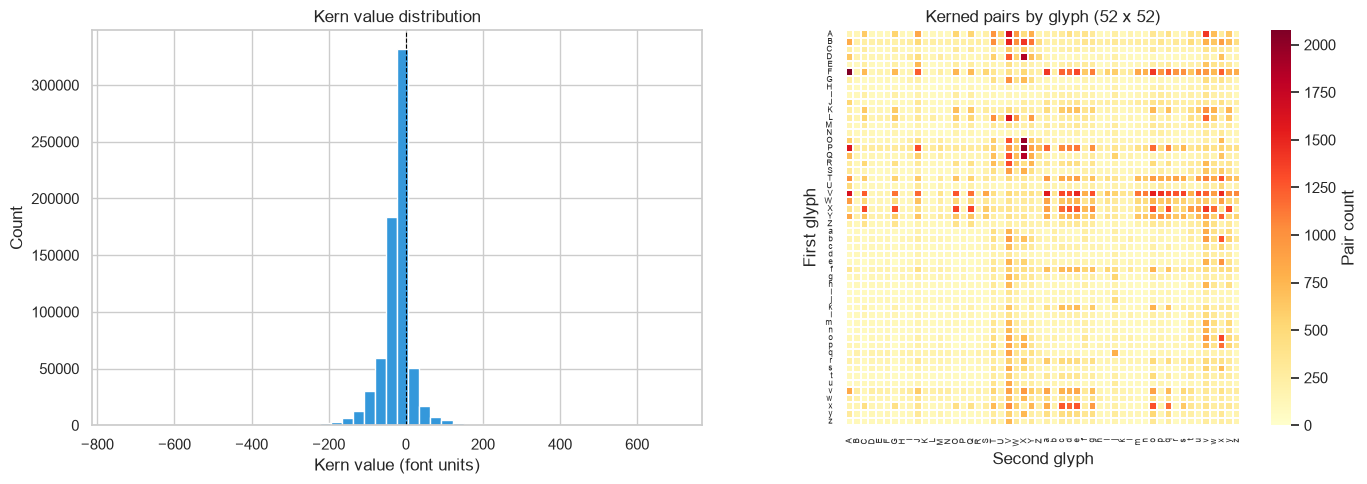

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(pairs_df["kern"], bins=50, color="#3498db", edgecolor="white")
axes[0].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_xlabel("Kern value (font units)")
axes[0].set_ylabel("Count")
axes[0].set_title("Kern value distribution")

latin = list(LATIN_52)
pivot = pairs_df.pivot_table(index="glyph1", columns="glyph2", values="kern", aggfunc="count", fill_value=0)
pivot = pivot.reindex(index=latin, columns=latin, fill_value=0)
vmax = pivot.values.max()
sns.heatmap(pivot, ax=axes[1], cmap="YlOrRd", cbar_kws={"label": "Pair count"},
            xticklabels=True, yticklabels=True, square=True, linewidths=0.1, vmin=0, vmax=vmax)
axes[1].set_title("Kerned pairs by glyph (52 x 52)")
axes[1].set_xlabel("Second glyph")
axes[1].set_ylabel("First glyph")
axes[1].tick_params(axis="both", labelsize=6)

plt.tight_layout()
plt.show()